# 데이터 불러오기


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('Crop_recommendation.csv')

# 데이터 탐색


In [3]:
df.shape

(2200, 8)

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
n_classes = df['label'].nunique()
print(f'작물 종류: {n_classes}가지')

작물 종류: 22가지


In [9]:
df['label'].value_counts()

label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

# 본격 시각화


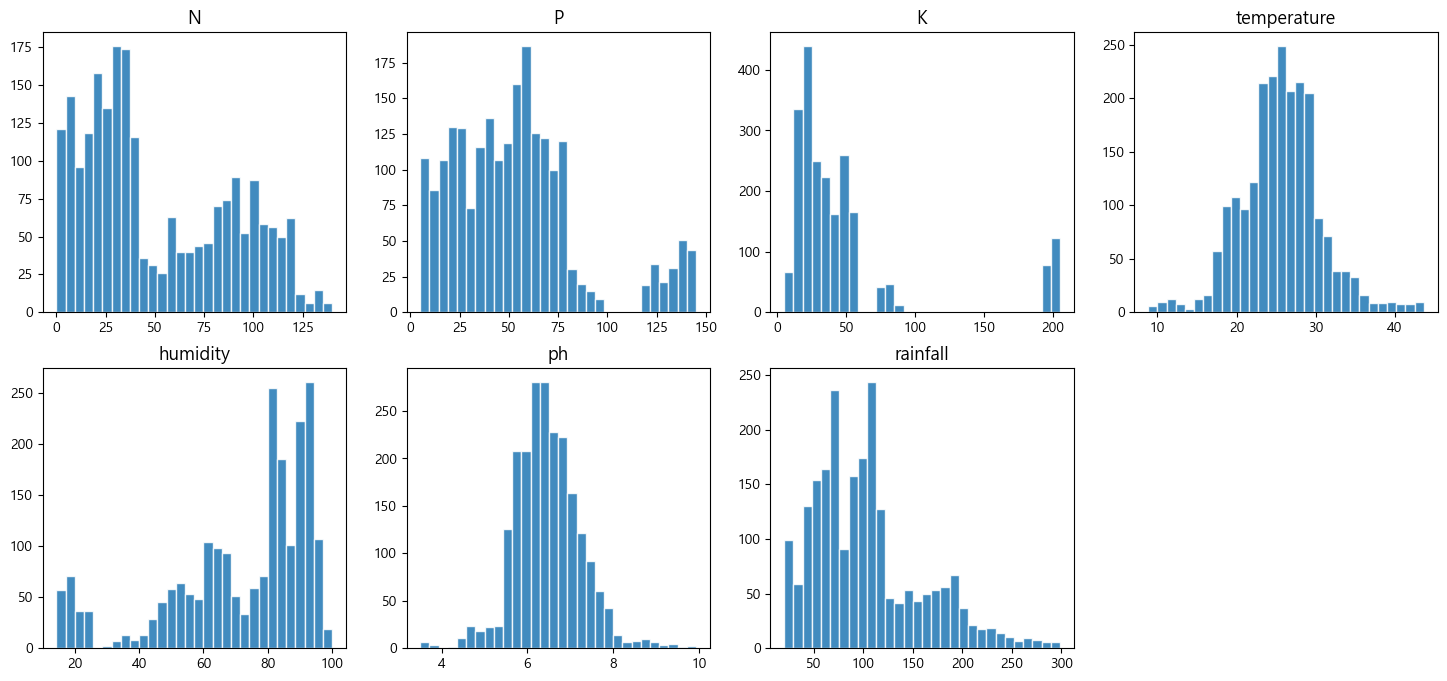

In [10]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=13)
axes[7].set_visible(False)

- → N, P, K: 특정 범위에 집중된 분포
- → temperature, humidity: 정규분포에 가까운 모양
- → rainfall: 오른쪽 꼬리 분포 (일부 고강수 샘플 존재)


<Axes: >

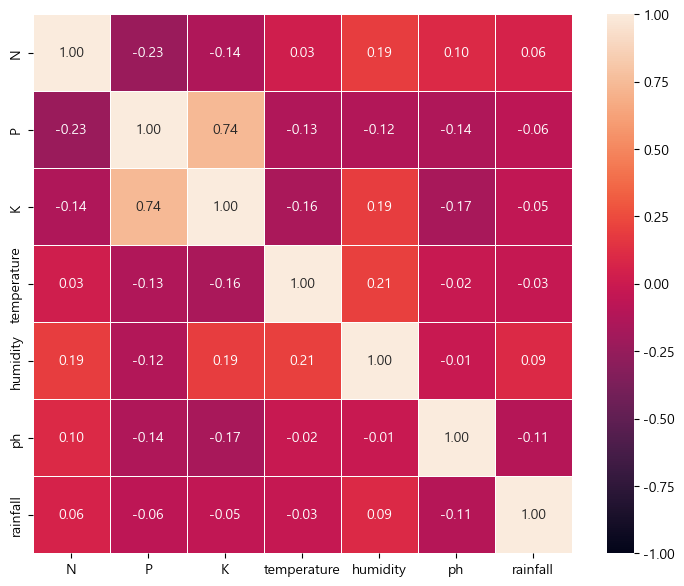

In [11]:
plt.figure(figsize=(9, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f',vmin=-1, vmax=1, square=True, linewidths=0.5)

- → K-P 상관관계 높음 (약 0.74) → 두 특성 간 관련성 존재
- → 나머지 특성들은 상관관계 낮음 → 독립적인 정보 제공


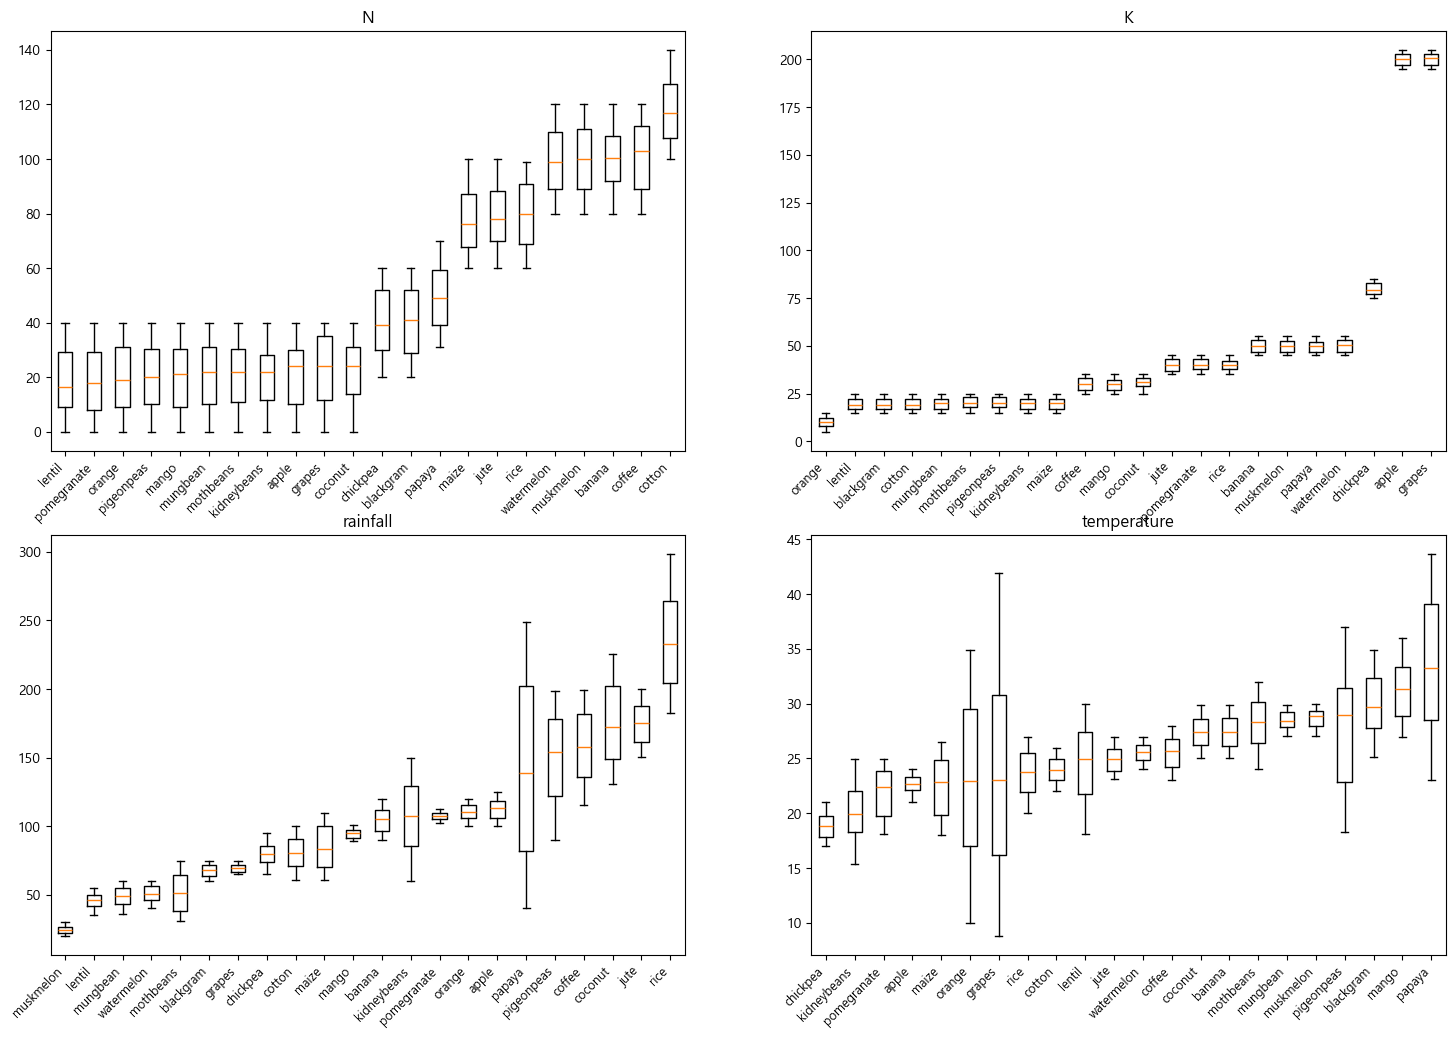

In [12]:
key_feats = ['N', 'K', 'rainfall', 'temperature']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, feat in zip(axes.flatten(), key_feats):
    crop_order = df.groupby('label')[feat].median().sort_values().index.tolist()
    crop_data = [df[df['label'] == c][feat].values for c in crop_order]
    ax.boxplot(crop_data, labels=crop_order)
    ax.set_xticklabels(crop_order, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{feat}')

- → 작물마다 특성값 범위가 뚜렷하게 다름 → 분류 가능성 높음
- → apple/grapes: 낮은 강수량, coffee: 높은 강수량이 특징적


<Axes: ylabel='label'>

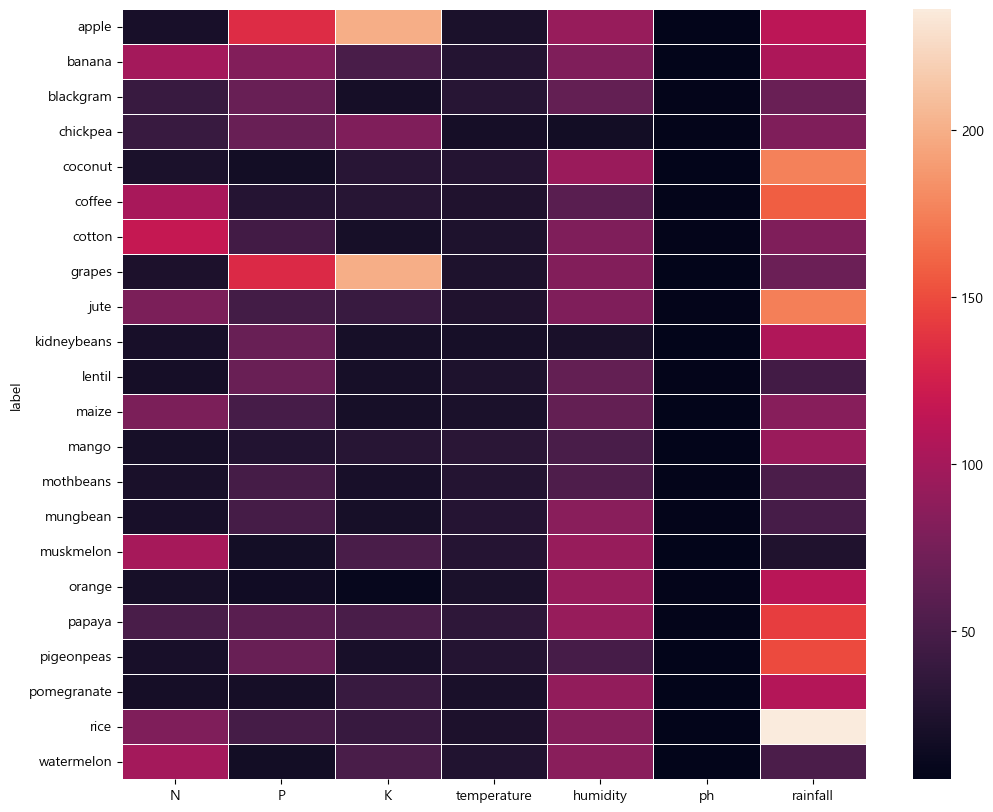

In [13]:
crop_mean = df.groupby("label")[features].mean()

plt.figure(figsize=(12, 10))
sns.heatmap(crop_mean,  linewidths=0.5, annot=False)

In [14]:
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)).sum()
    print(f'  {feat}: {n_out}개 ({n_out/len(df):.2%})')

  N: 0개 (0.00%)
  P: 138개 (6.27%)
  K: 200개 (9.09%)
  temperature: 86개 (3.91%)
  humidity: 30개 (1.36%)
  ph: 57개 (2.59%)
  rainfall: 100개 (4.55%)


# ML


In [15]:
# 전처리
X = df[features].copy()
y = df['label'].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f'클래스 수: {len(le.classes_)}')
print(f'클래스 목록: {list(le.classes_)}')
print()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

클래스 수: 22
클래스 목록: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']



In [16]:
baseline_models = {
    'Decision Tree':      (DecisionTreeClassifier(random_state=42), False),
    'Random Forest':      (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'Gradient Boosting':  (GradientBoostingClassifier(random_state=42), False),
    'KNN':                (KNeighborsClassifier(), True),
    'SVM':                (SVC(random_state=42), True),
    'Logistic Regression':(LogisticRegression(max_iter=1000, random_state=42), True),
}

baseline_results = {}
for name, (model, use_scaled) in baseline_models.items():
    X_tr = X_train_sc if use_scaled else X_train
    X_te = X_test_sc  if use_scaled else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    baseline_results[name] = {
        'Accuracy':      round(accuracy_score(y_test, y_pred), 4),
        'F1 (weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
    }

baseline_df = pd.DataFrame(baseline_results).T

In [17]:
# 기본 모델 성능 비교
print(baseline_df.sort_values('Accuracy', ascending=False))

                     Accuracy  F1 (weighted)
Random Forest          0.9955         0.9955
Gradient Boosting      0.9886         0.9887
SVM                    0.9841         0.9840
Decision Tree          0.9795         0.9794
KNN                    0.9795         0.9793
Logistic Regression    0.9727         0.9725


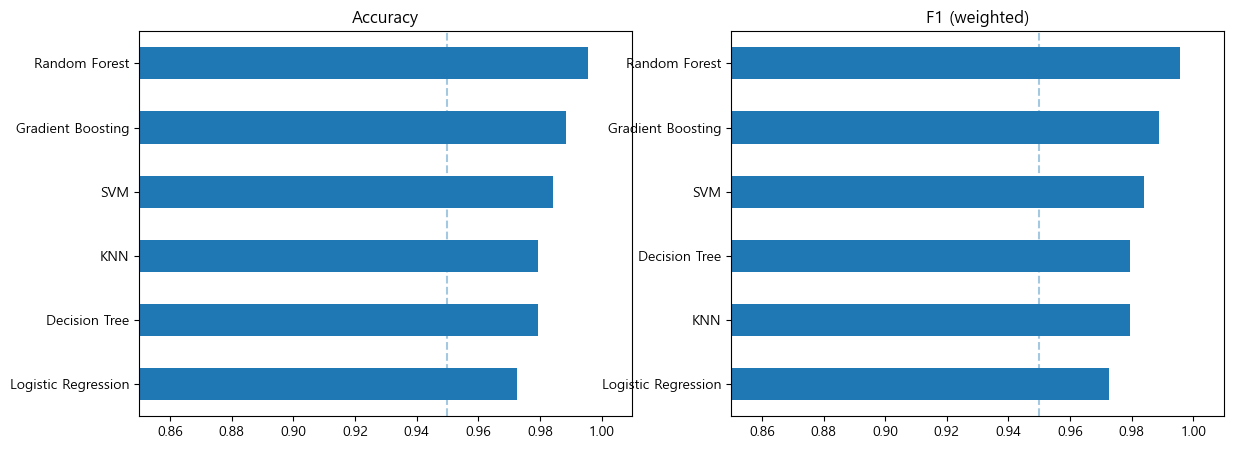

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['Accuracy', 'F1 (weighted)']):
    baseline_df[metric].sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xlim(0.85, 1.01)
    ax.axvline(x=0.95, linestyle='--', alpha=0.4)

- → Random Forest, SVM이 상위권
- → Logistic Regression 상대적으로 낮음 (비선형 경계 처리 한계)
- → Decision Tree 단독으로는 다소 불안정할 수 있음


In [19]:
param_dt = {
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy'],
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt, cv=5, scoring='accuracy', n_jobs=-1
)
gs_dt.fit(X_train, y_train)

print(f'파라미터: {gs_dt.best_params_}')
print(f'CV 최고 정확도: {gs_dt.best_score_:.4f}')

파라미터: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
CV 최고 정확도: 0.9858


In [20]:
# GridSearchCV - Random Forest
param_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf, cv=5, scoring='accuracy', n_jobs=-1
)
gs_rf.fit(X_train, y_train)

print(f'최적 파라미터: {gs_rf.best_params_}')
print(f'CV 최고 정확도: {gs_rf.best_score_:.4f}')

최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
CV 최고 정확도: 0.9960


In [21]:
# GridSearchCV - KNN

param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn, cv=5, scoring='accuracy', n_jobs=-1
)
gs_knn.fit(X_train_sc, y_train)

print(f'최적 파라미터: {gs_knn.best_params_}')
print(f'CV 최고 정확도: {gs_knn.best_score_:.4f}')

최적 파라미터: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
CV 최고 정확도: 0.9812


In [22]:
# GridSearchCV - SVM
param_svm = {
    'C':      [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto'],
}
gs_svm = GridSearchCV(
    SVC(random_state=42),
    param_svm, cv=5, scoring='accuracy', n_jobs=-1
)
gs_svm.fit(X_train_sc, y_train)

print(f'최적 파라미터: {gs_svm.best_params_}')
print(f'CV 최고 정확도: {gs_svm.best_score_:.4f}')

최적 파라미터: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
CV 최고 정확도: 0.9852


In [ ]:
# GridSearchCV - Gradient Boosting
param_gb = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0],
}
gs_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb, cv=5, scoring='accuracy', n_jobs=-1
)
gs_gb.fit(X_train, y_train)

print(f'최적 파라미터: {gs_gb.best_params_}')
print(f'CV 최고 정확도: {gs_gb.best_score_:.4f}')

In [ ]:
# 튜닝 후 테스트셋 성능 비교
tuned_configs = {
    'Decision Tree':     (gs_dt.best_estimator_, False),
    'Random Forest':     (gs_rf.best_estimator_, False),
    'Gradient Boosting': (gs_gb.best_estimator_, False),
    'KNN':               (gs_knn.best_estimator_, True),
    'SVM':               (gs_svm.best_estimator_, True),
}

tuned_results = {}
for name, (model, use_scaled) in tuned_configs.items():
    X_te = X_test_sc if use_scaled else X_test
    y_pred = model.predict(X_te)
    tuned_results[name] = {
        'Accuracy':      round(accuracy_score(y_test, y_pred), 4),
        'F1 (weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
    }

tuned_df = pd.DataFrame(tuned_results).T

print(tuned_df.sort_values('Accuracy', ascending=False))

=== 튜닝 후 모델 성능 비교 ===
                   Accuracy  F1 (weighted)
Random Forest        0.9955         0.9955
Gradient Boosting    0.9932         0.9932
SVM                  0.9886         0.9887
KNN                  0.9818         0.9817
Decision Tree        0.9795         0.9794


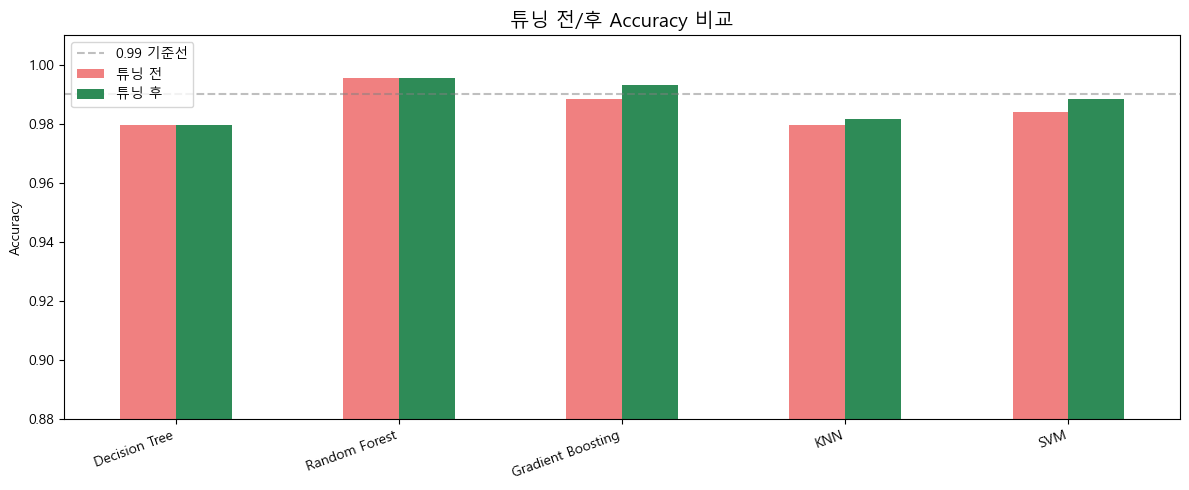

In [ ]:
# 튜닝 전/후 성능 비교 시각화
common = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'KNN', 'SVM']
compare = pd.DataFrame({
    '튜닝 전': baseline_df.loc[common, 'Accuracy'],
    '튜닝 후': tuned_df['Accuracy'],
})

compare.plot(kind='bar', figsize=(12, 5))
plt.title('튜닝 전/후 Accuracy 비교', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.88, 1.01)
plt.xticks(rotation=20, ha='right')
plt.axhline(y=0.99, linestyle='--', alpha=0.5, label='0.99 기준선')

- → 튜닝 후 전반적으로 성능 향상
- → Random Forest, SVM이 0.99 이상으로 가장 우수
- → Gradient Boosting도 경쟁력 있음

- 최종 모델 선정: Random Forest


In [ ]:
best_model = gs_rf.best_estimator_
y_pred_final = best_model.predict(X_test)

acc_final = accuracy_score(y_test, y_pred_final)
f1_final  = f1_score(y_test, y_pred_final, average='weighted')

print(f'Acc : {acc_final:.4f}')
print(f'F1 : {f1_final:.4f}')

# 분류 결과 출력
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

  최종 모델: Random Forest (GridSearch CV 튜닝)
  Accuracy : 0.9955
  F1-score : 0.9955

분류 상세 리포트:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.

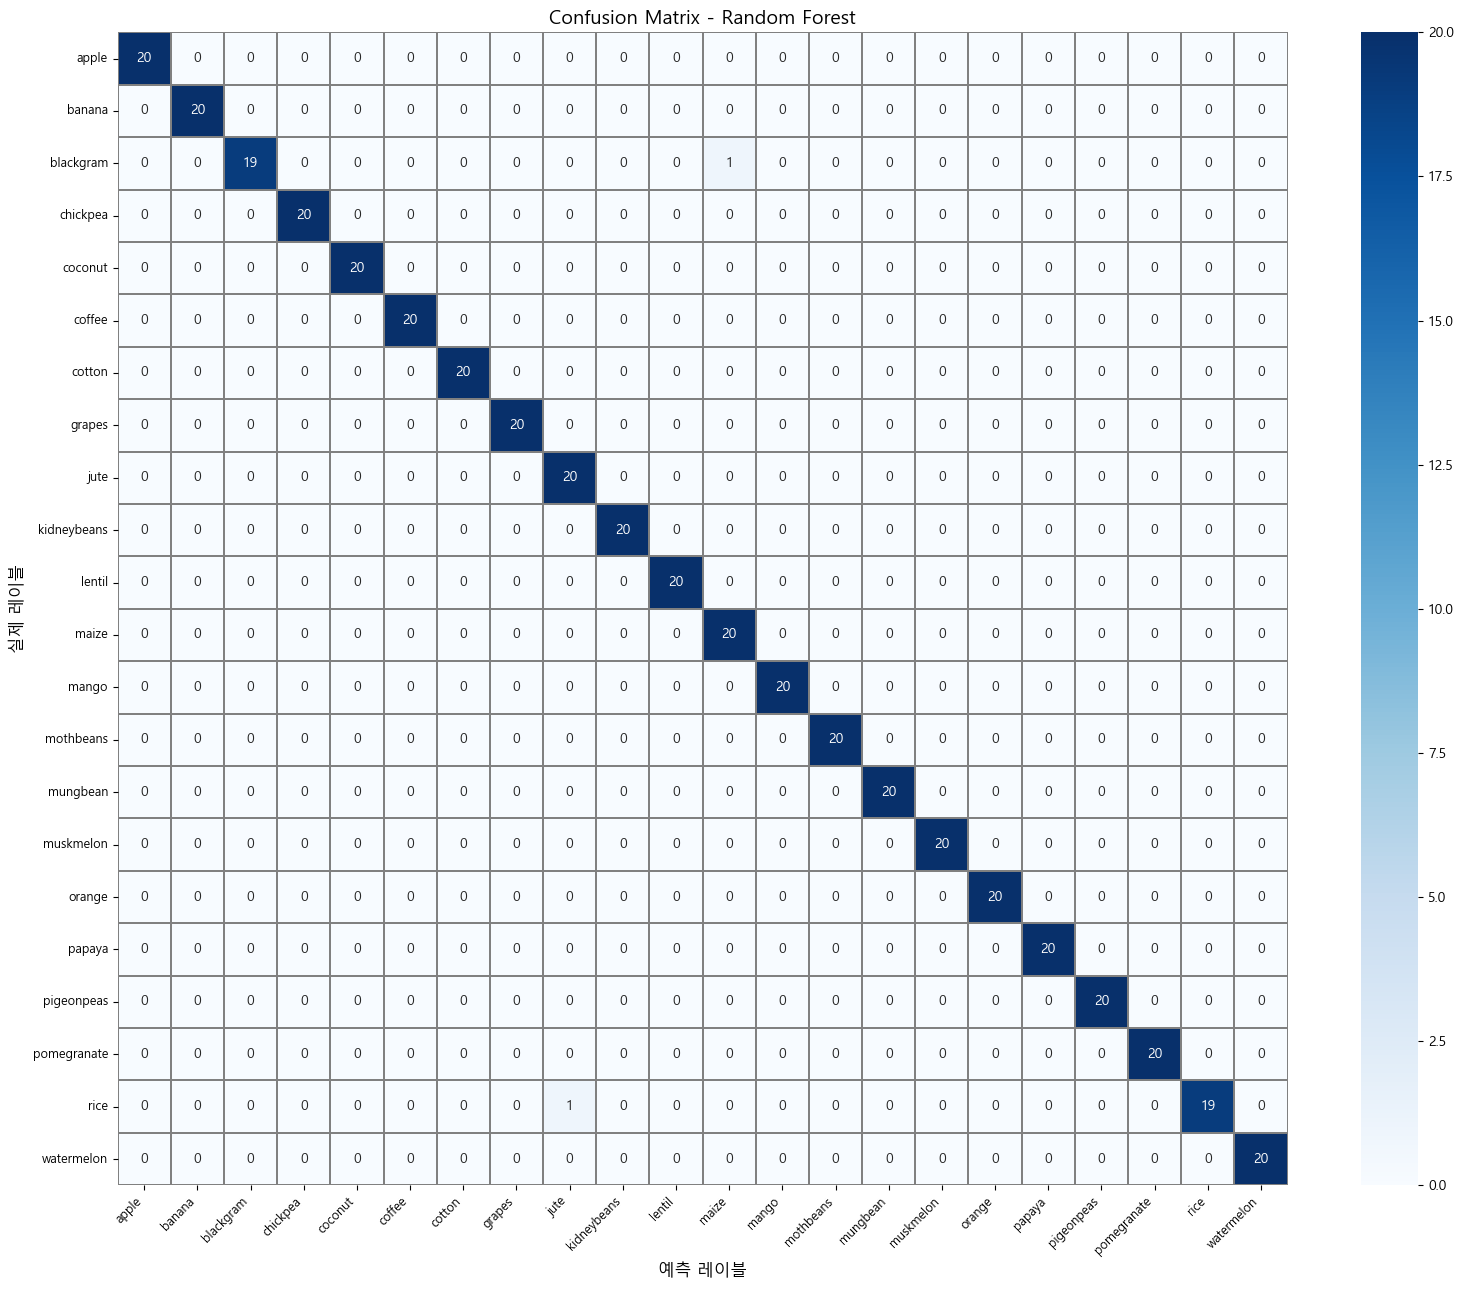

In [ ]:
# 혼동 행렬
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,  linewidths=0.3)
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.ylabel('실제 ', fontsize=12)
plt.xlabel('예측 ', fontsize=12)

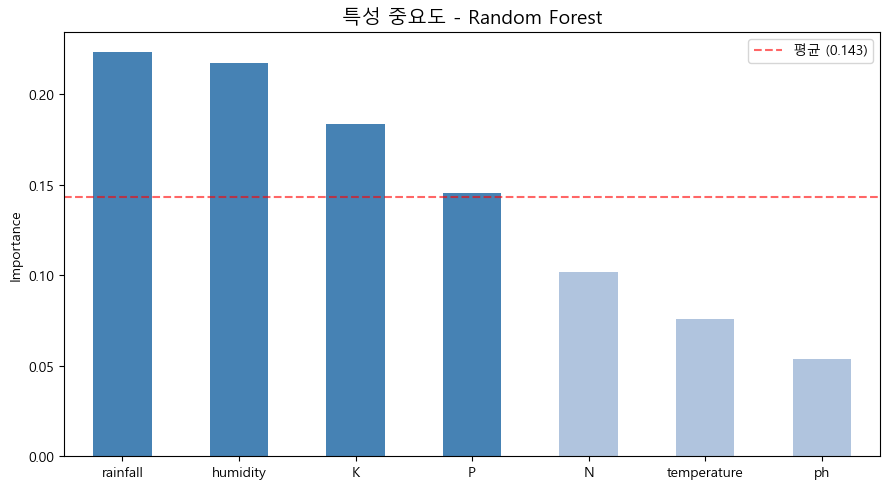

In [ ]:
# 특성 중요도 분석
feat_imp  = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
mean_imp  = feat_imp.mean()

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar')
plt.axhline(y=mean_imp, linestyle='--', alpha=0.6,
            label=f'평균 ({mean_imp:.3f})')
plt.title('특성 중요도 - Random Forest', fontsize=14)
plt.ylabel('Importance')
plt.xticks(rotation=0)
plt.legend()

- → humidity, rainfall, K가 분류에 가장 큰 기여
- → ph, N, temperature도 상당한 역할
- → P는 상대적으로 낮은 중요도 (K와 상관관계 높아 중복 정보 많음)


In [ ]:
# 10-fold Stratified Cross Validation으로 최종 신뢰성 검증
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y_enc, cv=cv, scoring='accuracy')

for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i:2d}: {score:.4f}')

print(f'  평균 정확도  : {cv_scores.mean():.4f}')
print(f'  표준편차     : {cv_scores.std():.4f}')
print(f'  95% 신뢰구간 : [{cv_scores.mean() - 2*cv_scores.std():.4f}, {cv_scores.mean() + 2*cv_scores.std():.4f}]')

=== 10-fold Stratified CV 결과 ===
  Fold  1: 1.0000
  Fold  2: 0.9909
  Fold  3: 0.9955
  Fold  4: 0.9909
  Fold  5: 1.0000
  Fold  6: 1.0000
  Fold  7: 0.9955
  Fold  8: 0.9955
  Fold  9: 0.9955
  Fold 10: 0.9909

  평균 정확도  : 0.9955
  표준편차     : 0.0035
  95% 신뢰구간 : [0.9884, 1.0025]


- → 표준편차 매우 낮음 → 폴드마다 안정적인 성능
- → 과적합 없이 일반화 성능 높음


# 모델 및 전처리 객체 저장


In [ ]:
joblib.dump(best_model, 'crop_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(le,         'label_encoder.pkl')

print('저장 완료')
print('  crop_model.pkl      : 학습된 Random Forest 모델')
print('  scaler.pkl          : StandardScaler')
print('  label_encoder.pkl   : LabelEncoder (작물명 복원용)')

저장 완료
  crop_model.pkl      : 학습된 Random Forest 모델
  scaler.pkl          : StandardScaler
  label_encoder.pkl   : LabelEncoder (작물명 복원용)
